# 01. Manifest Construction & Data Pipeline

In [44]:
import re
import csv
import argparse
import math
import json
import random

from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

In [45]:
ROOT        = Path("~/Desktop/Thesis/TR-6").expanduser()
MANIFESTS   = Path("~/Desktop/convscript/Code/Manifest/manifests").expanduser()

In [46]:
def _mean(values):
    return round(sum(values) / len(values), 4) if values else None

def _std(values):
    if not values or len(values) < 2:
        return 0.0
    m = sum(values) / len(values)
    return round((sum((x - m) ** 2 for x in values) / (len(values) - 1)) ** 0.5, 4)

# 2. Methane Parsing

In [47]:
SESSION_NAMES = {1: "morning", 2: "afternoon", 3: "evening"}

RE_DAY     = re.compile(r"^Day\s+(\d+)", re.IGNORECASE)
RE_CASE    = re.compile(r"^case\s+(\d+)", re.IGNORECASE)
RE_R_SIDE  = re.compile(r"^R\s*$")
RE_L_SIDE  = re.compile(r"^L\s*$")
RE_NULL    = re.compile(r"^-null-", re.IGNORECASE)
RE_READING = re.compile(
    r"ADC:\s*(\d+)\s*\|\s*Rs:\s*([\d.]+)\s*k?Ω?\s*\|\s*Rs/R0:\s*([\d.]+)\s*\|\s*Methane:\s*([\d.]+)\s*ppm",
    re.IGNORECASE,
)

In [48]:
def parse_methane_file(filepath):
    filepath = Path(filepath)
    text = filepath.read_text(encoding="utf-8", errors="replace")
    lines = [line.strip() for line in text.splitlines()]

    records = []
    current_day     = None
    current_case    = None
    current_side    = None   # "R" or "L"
    is_null         = False
    right_ppm   = []
    right_rs_r0 = []
    left_ppm    = []
    left_rs_r0  = []

    def flush_case():
        if current_day is None or current_case is None:
            return
        all_ppm = right_ppm + left_ppm
        records.append({
            "day":               current_day,
            "session":           current_case,
            "session_name":      SESSION_NAMES.get(current_case, f"case{current_case}"),
            "present":           not is_null,
            "right_ppm_mean":    _mean(right_ppm),
            "left_ppm_mean":     _mean(left_ppm),
            "combined_ppm_mean": _mean(all_ppm),
            "combined_ppm_std":  _std(all_ppm),
            "right_rs_r0_mean":  _mean(right_rs_r0),
            "left_rs_r0_mean":   _mean(left_rs_r0),
            "reading_count_R":   len(right_ppm),
            "reading_count_L":   len(left_ppm),
        })

    for line in lines:
        if not line:
            continue

        # Day header
        m = RE_DAY.match(line)
        if m:
            if current_case is not None:
                flush_case()
            current_day  = int(m.group(1))
            current_case = None
            current_side = None
            is_null      = False
            right_ppm, right_rs_r0, left_ppm, left_rs_r0 = [], [], [], []
            continue

        # Case header
        m = RE_CASE.match(line)
        if m:
            if current_case is not None:
                flush_case()
            current_case = int(m.group(1))
            current_side = None
            is_null      = False
            right_ppm, right_rs_r0, left_ppm, left_rs_r0 = [], [], [], []
            continue

        # Null marker
        if RE_NULL.match(line):
            is_null = True
            continue

        # Side marker
        if RE_R_SIDE.match(line):
            current_side = "R"
            continue
        if RE_L_SIDE.match(line):
            current_side = "L"
            continue

        # Data reading 
        m = RE_READING.match(line)
        if m and current_side and not is_null:
            ppm   = float(m.group(4))
            rs_r0 = float(m.group(3))
            if current_side == "R":
                right_ppm.append(ppm)
                right_rs_r0.append(rs_r0)
            elif current_side == "L":
                left_ppm.append(ppm)
                left_rs_r0.append(rs_r0)

    if current_case is not None:
        flush_case()
    return records

In [49]:
def parse_methane_to_day_dict(filepath):
    records = parse_methane_file(filepath)
    result = {}
    for r in records:
        day = r["day"]
        ses = r["session"]
        if day not in result:
            result[day] = {}
        result[day][ses] = r
    return result

sample_txt = ROOT / "Classified/Tomato/Not_spoiled/Methane_gas_readings.txt"
if sample_txt.exists():
    records = parse_methane_file(sample_txt)
    print(f"Parsed {len(records)} session records\n")
    for r in records[:6]:   # show first 6
        status   = "OK" if r["present"] else "NULL"
        combined = f"{r['combined_ppm_mean']:.2f} ppm" if r["combined_ppm_mean"] else "—"
        print(f"  Day {r['day']:>2}  {r['session_name']:<11} [{status}]"
              f"  combined={combined}"
              f"  (R={r['reading_count_R']}, L={r['reading_count_L']})")
else:
    print(f"File not found: {sample_txt}")

Parsed 132 session records

  Day  1  morning     [OK]  combined=18.20 ppm  (R=25, L=13)
  Day  1  afternoon   [OK]  combined=16.91 ppm  (R=24, L=21)
  Day  1  evening     [OK]  combined=16.98 ppm  (R=14, L=14)
  Day  2  morning     [OK]  combined=15.39 ppm  (R=16, L=13)
  Day  2  afternoon   [OK]  combined=15.12 ppm  (R=13, L=14)
  Day  2  evening     [OK]  combined=17.32 ppm  (R=14, L=13)


# 3. Manifest & Construction

In [50]:
FRUITS = ["Banana", "Carrot", "Guava", "Mango", "Indian_Gooseberry", "Tomato"]
SESSIONS = ["morning", "afternoon", "evening"]
SESSION_IDX = {"morning": 0, "afternoon": 1, "evening": 2}
SESSION_MAP = {"morning": 1, "afternoon": 2, "evening": 3}

SESSION_HOUR_BUCKETS = {
    "morning":   (5,  11),
    "afternoon": (12, 16),
    "evening":   (16, 19),
}

FRUIT_COLORS = {
    "Banana":            "#F5C518",
    "Carrot":            "#FF6B35",
    "Guava":             "#7BC67E",
    "Indian_Gooseberry": "#9B59B6",
    "Mango":             "#FF8C00",
    "Tomato":            "#E74C3C",
}

IR_PATTERN = re.compile(
    r"(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$",
    re.IGNORECASE,
)
SRGB_PATTERN = re.compile(r"(\d{8})_(\d{6})", re.IGNORECASE)

In [51]:
def parse_ir_filename(filename):
    m = IR_PATTERN.search(filename)
    if not m:
        return None
    date_str, time_str, t_min_str, t_max_str = m.groups()
    return date_str, hour_to_session(int(time_str[:2])), float(t_min_str), float(t_max_str)

def parse_srgb_filename(filename):
    m = SRGB_PATTERN.search(filename)
    if not m:
        return None
    date_str, time_str = m.groups()
    return date_str, hour_to_session(int(time_str[:2]))

In [52]:
def date_ord(d):
    return int(d)

def hour_to_session(hour):
    for name, (lo, hi) in SESSION_HOUR_BUCKETS.items():
        if lo <= hour < hi:
            return name
    return "unknown"

In [53]:
def scan_srgb_folder(folder):
    result = defaultdict(lambda: defaultdict(int))
    if not folder.exists():
        return {}
    for f in folder.iterdir():
        p = parse_srgb_filename(f.name)
        if p and p[1] != "unknown":
            result[p[0]][p[1]] += 1
    return dict(result)

def find_ir_folder(base):
    for name in ["IR_fusion_images", "IR_Fusion_images", "ir_fusion_images"]:
        p = base / name
        if p.exists():
            return p
    return base / "IR_fusion_images"

def scan_ir_folder(folder):
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in folder.iterdir():
        p = parse_ir_filename(f.name)
        if p and p[1] != "unknown":
            result[p[0]][p[1]].append((p[2], p[3]))
    return dict(result)

def scan_ir_session_scalars(folder):
    result = defaultdict(lambda: defaultdict(list))  # date -> session -> [(tmin, tmax)]
    if not folder.exists():
        return {}
    for f in folder.iterdir():
        m = IR_PATTERN.search(f.name)
        if not m:
            continue
        date_str, time_str, tmin_str, tmax_str = m.groups()
        hour = int(time_str[:2])
        session = hour_to_session(hour)
        if session == "unknown":
            continue
        result[date_str][session].append((float(tmin_str), float(tmax_str)))

    out = {}
    for date_str, sessions in result.items():
        out[date_str] = {}
        for session, temps in sessions.items():
            tmin_mean  = round(sum(t[0] for t in temps) / len(temps), 2)
            tmax_mean  = round(sum(t[1] for t in temps) / len(temps), 2)
            trange_mean = round(tmax_mean - tmin_mean, 2)
            out[date_str][session] = {
                "tmin":  tmin_mean,
                "tmax":  tmax_mean,
                "trange": trange_mean,
            }
    return out

def load_methane(base_folder):
    result = {}
    for txt_file in base_folder.glob("Methane_gas_readings*.txt"):
        try:
            result.update(parse_methane_to_day_dict(txt_file))
        except Exception as e:
            print(f"    WARNING: {txt_file.name}: {e}")
    return result

### Manifest Build

In [54]:
def build_fruit_manifest(root, fruit, out_dir):
    ns_base     = root / "Classified" / fruit / "Not_spoiled"
    sp_base     = root / "Classified" / fruit / "Spoiled"
    normal_base = root / "Normal" / fruit

    ns_ir   = scan_ir_folder(find_ir_folder(ns_base))
    ns_srgb = scan_srgb_folder(ns_base / "sRGB_images")
    sp_ir   = scan_ir_folder(find_ir_folder(sp_base))
    sp_srgb = scan_srgb_folder(sp_base / "sRGB_images")
    
    if fruit.lower() == "banana":
        sp_srgb_dates = set(sp_srgb.keys())
        sp_ir = {date: sessions for date, sessions in sp_ir.items() if date in sp_srgb_dates}
        normal_ir = scan_ir_folder(find_ir_folder(normal_base))
        for date in sp_srgb_dates:
            if date not in sp_ir and date in normal_ir:
                sp_ir[date] = normal_ir[date]

    ns_dates = sorted(set(ns_ir) | set(ns_srgb), key=date_ord)
    sp_dates = sorted(set(sp_ir) | set(sp_srgb), key=date_ord)

    ns_day_map = {d: i+1            for i, d in enumerate(ns_dates)}
    sp_day_map = {d: i+1+len(ns_dates) for i, d in enumerate(sp_dates)}

    ns_methane = load_methane(ns_base)
    sp_methane = load_methane(sp_base)

    rows = []

    def add_rows(dates, day_map, ir_data, srgb_data, methane, label, offset):
        for date_str in dates:
            global_day = day_map[date_str]
            local_day  = global_day - offset
            methane_lookup_day = global_day

            ir = ir_data.get(date_str, {})
            ir_m = len(ir.get("morning",   []))
            ir_a = len(ir.get("afternoon", []))
            ir_e = len(ir.get("evening",   []))
            temps = [t for s in ir.values() for t in s]
            tmin = round(sum(t[0] for t in temps)/len(temps), 2) if temps else ""
            tmax = round(sum(t[1] for t in temps)/len(temps), 2) if temps else ""
            trng = round(tmax - tmin, 2) if temps else ""

            sg = srgb_data.get(date_str, {})
            sg_m = sg.get("morning",   0)
            sg_a = sg.get("afternoon", 0)
            sg_e = sg.get("evening",   0)

            dm = methane.get(methane_lookup_day, {})
            r1, r2, r3 = dm.get(1,{}), dm.get(2,{}), dm.get(3,{})
            p1 = r1.get("present", False)
            p2 = r2.get("present", False)
            p3 = r3.get("present", False)
            ppm1 = r1.get("combined_ppm_mean","") if p1 else ""
            ppm2 = r2.get("combined_ppm_mean","") if p2 else ""
            ppm3 = r3.get("combined_ppm_mean","") if p3 else ""
            ppms = [v for v in [ppm1,ppm2,ppm3] if v != ""]
            ppm_mean = round(sum(ppms)/len(ppms),4) if ppms else ""

            rows.append({
                "fruit": fruit, "label": label,
                "actual_date": date_str,
                "corrected_day_index": global_day,
                "local_day_index": local_day,
                "ir_morning_count": ir_m, "ir_afternoon_count": ir_a, "ir_evening_count": ir_e,
                "ir_total_sessions": sum(1 for x in [ir_m,ir_a,ir_e] if x>0),
                "ir_t_min_mean": tmin, "ir_t_max_mean": tmax, "ir_t_range_mean": trng,
                "srgb_morning_count": sg_m, "srgb_afternoon_count": sg_a, "srgb_evening_count": sg_e,
                "srgb_total_sessions": sum(1 for x in [sg_m,sg_a,sg_e] if x>0),
                "methane_morning_present": p1, "methane_afternoon_present": p2, "methane_evening_present": p3,
                "methane_total_sessions": sum([p1,p2,p3]),
                "methane_morning_ppm": ppm1, "methane_afternoon_ppm": ppm2, "methane_evening_ppm": ppm3,
                "methane_day_mean_ppm": ppm_mean,
                "sequence_break": "", "days_until_spoilage": "", "exclude": "", "notes": "",
            })

    add_rows(ns_dates, ns_day_map, ns_ir, ns_srgb, ns_methane, "not_spoiled", offset=0)
    add_rows(sp_dates, sp_day_map, sp_ir, sp_srgb, sp_methane, "spoiled",     offset=len(ns_dates))

    out_dir.mkdir(parents=True, exist_ok=True)
    slug = fruit.lower().replace(" ", "_")
    out_path = out_dir / f"{slug}_manifest.csv"
    fieldnames = [
        "fruit","label","actual_date","corrected_day_index","local_day_index",
        "ir_morning_count","ir_afternoon_count","ir_evening_count","ir_total_sessions",
        "ir_t_min_mean","ir_t_max_mean","ir_t_range_mean",
        "srgb_morning_count","srgb_afternoon_count","srgb_evening_count","srgb_total_sessions",
        "methane_morning_present","methane_afternoon_present","methane_evening_present",
        "methane_total_sessions","methane_morning_ppm","methane_afternoon_ppm","methane_evening_ppm",
        "methane_day_mean_ppm","sequence_break","days_until_spoilage","exclude","notes",
    ]
    with open(out_path, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()
        csv.DictWriter(f, fieldnames=fieldnames).writerows(rows)

    return rows

In [55]:
all_rows = []
for fruit in FRUITS:
    all_rows.extend(build_fruit_manifest(ROOT, fruit, MANIFESTS))

out_path = MANIFESTS / "master_manifest.csv"
with open(out_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()))
    w.writeheader()
    w.writerows(all_rows)
print("Done")


Done


### Updation

In [56]:
NEW_COLUMNS = [
    "ir_morning_tmin",   "ir_morning_tmax",   "ir_morning_trange",
    "ir_afternoon_tmin", "ir_afternoon_tmax", "ir_afternoon_trange",
    "ir_evening_tmin",   "ir_evening_tmax",   "ir_evening_trange",

    "methane_morning_std",   "methane_morning_left",   "methane_morning_right",
    "methane_afternoon_std", "methane_afternoon_left", "methane_afternoon_right",
    "methane_evening_std",   "methane_evening_left",   "methane_evening_right",
]

In [57]:
def update_fruit_manifest(root, fruit, manifests_dir):
    slug = fruit.lower().replace(" ", "_")
    csv_path = manifests_dir / f"{slug}_manifest.csv"

    if not csv_path.exists():
        print(f"  SKIP: {csv_path.name} not found")
        return []

    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        original_fields = reader.fieldnames
        rows = list(reader)

    ns_base = root / "Classified" / fruit / "Not_spoiled"
    sp_base = root / "Classified" / fruit / "Spoiled"

    ns_ir_scalars = scan_ir_session_scalars(find_ir_folder(ns_base))
    sp_ir_scalars = scan_ir_session_scalars(find_ir_folder(sp_base))

    if fruit.lower() == "banana":
        normal_base = root / "Normal" / fruit
        normal_ir_scalars = scan_ir_session_scalars(find_ir_folder(normal_base))
        for date, sessions in normal_ir_scalars.items():
            if date not in sp_ir_scalars:
                sp_ir_scalars[date] = sessions

    ns_methane = load_methane(ns_base)  
    sp_methane = load_methane(sp_base)

    ns_rows = [r for r in rows if r["label"] == "not_spoiled"]
    ns_count = len(ns_rows)

    for row in rows:
        label      = row["label"]
        date_str   = row["actual_date"]
        global_day = int(row["corrected_day_index"])

        ir_scalars = ns_ir_scalars if label == "not_spoiled" else sp_ir_scalars
        day_ir = ir_scalars.get(date_str, {})

        methane = ns_methane if label == "not_spoiled" else sp_methane
        day_methane = methane.get(global_day, {})

        for session in SESSIONS:
            sess_ir = day_ir.get(session, {})
            row[f"ir_{session}_tmin"]   = sess_ir.get("tmin",   "")
            row[f"ir_{session}_tmax"]   = sess_ir.get("tmax",   "")
            row[f"ir_{session}_trange"] = sess_ir.get("trange", "")

        for session, sess_num in SESSION_MAP.items():
            sess_m = day_methane.get(sess_num, {})
            present = sess_m.get("present", False)
            row[f"methane_{session}_std"]   = sess_m.get("combined_ppm_std",  "") if present else ""
            row[f"methane_{session}_left"]  = sess_m.get("left_ppm_mean",     "") if present else ""
            row[f"methane_{session}_right"] = sess_m.get("right_ppm_mean",    "") if present else ""

    existing_new = [c for c in NEW_COLUMNS if c in (original_fields or [])]
    truly_new    = [c for c in NEW_COLUMNS if c not in (original_fields or [])]
    all_fields   = list(original_fields) + truly_new

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=all_fields, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)
    return rows

In [58]:
def update_master(manifests_dir, all_rows):
    master_path = manifests_dir / "master_manifest.csv"
    if not all_rows:
        return
    with open(master_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()), extrasaction="ignore")
        writer.writeheader()
        writer.writerows(all_rows)

In [59]:
all_rows = []
for fruit in FRUITS:
    rows = update_fruit_manifest(ROOT, fruit, MANIFESTS)
    all_rows.extend(rows)
update_master(MANIFESTS, all_rows)
print("Done")

Done


# 4. Gas Normalization Stats

In [60]:
def compute_stats(manifests_dir: Path, out_path: Path):
    master_path = manifests_dir / "master_manifest.csv"
    with open(master_path, newline="") as f:
        rows = list(csv.DictReader(f))

    train_rows = [r for r in rows
                  if r.get("split", "").strip().lower() == "train"
                  and r.get("exclude", "").strip().upper() != "TRUE"]

    print(f"Training rows: {len(train_rows)}")
    
    gas_values = defaultdict(lambda: {
        "mean_ppm":  [],
        "left_ppm":  [],
        "right_ppm": [],
        "std_ppm":   [],
    })

    for row in train_rows:
        fruit = row["fruit"]
        for session in SESSIONS:
            present = row.get(f"methane_{session}_present", "").strip().upper() == "TRUE"
            if not present:
                continue

            def safe_float(key):
                try:
                    return float(row.get(key, ""))
                except (ValueError, TypeError):
                    return None

            mean_ppm  = safe_float(f"methane_{session}_ppm")
            left_ppm  = safe_float(f"methane_{session}_left")
            right_ppm = safe_float(f"methane_{session}_right")
            std_ppm   = safe_float(f"methane_{session}_std")

            key = (fruit, session)
            if mean_ppm  is not None: gas_values[key]["mean_ppm"].append(mean_ppm)
            if left_ppm  is not None: gas_values[key]["left_ppm"].append(left_ppm)
            if right_ppm is not None: gas_values[key]["right_ppm"].append(right_ppm)
            if std_ppm   is not None: gas_values[key]["std_ppm"].append(std_ppm)

    stats = {}
    print(f"\n{'Fruit':<22} {'Session':<12} {'N':>4} "
          f"{'mean_ppm_mean':>14} {'mean_ppm_std':>13}")
    print("-" * 70)

    for fruit in FRUITS:
        stats[fruit] = {}
        for session in SESSIONS:
            key = (fruit, session)
            vals = gas_values[key]

            def stat(arr):
                if not arr:
                    return {"mean": 0.0, "std": 1.0}
                a = np.array(arr)
                return {
                    "mean": float(np.mean(a)),
                    "std":  float(np.std(a)) if len(a) > 1 and np.std(a) > 1e-6 else 1.0
                }

            stats[fruit][session] = {
                "mean_ppm":  stat(vals["mean_ppm"]),
                "left_ppm":  stat(vals["left_ppm"]),
                "right_ppm": stat(vals["right_ppm"]),
                "std_ppm":   stat(vals["std_ppm"]),
                "n":         len(vals["mean_ppm"]),
            }

            n = len(vals["mean_ppm"])
            if n > 0:
                print(f"{fruit:<22} {session:<12} {n:>4} "
                      f"{stats[fruit][session]['mean_ppm']['mean']:>14.4f} "
                      f"{stats[fruit][session]['mean_ppm']['std']:>13.4f}")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        json.dump({
            "note": "Computed from training split only. Never recompute after splits are frozen.",
            "stats": stats,
        }, f, indent=2)

    print(f"\n   Saved to {out_path}")

In [61]:
GAS_NORM_OUT = Path("~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json").expanduser()
compute_stats(MANIFESTS, GAS_NORM_OUT)

Training rows: 0

Fruit                  Session         N  mean_ppm_mean  mean_ppm_std
----------------------------------------------------------------------

   Saved to /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json


# 5. Gas Normalization Plots

In [62]:
def load_gas_data(manifests_dir: Path):
    records = []
    master_path = manifests_dir / "master_manifest.csv"
    with open(master_path, newline="") as f:
        rows = list(csv.DictReader(f))

    for row in rows:
        if row.get("exclude", "").strip().upper() == "TRUE":
            continue
        fruit     = row["fruit"]
        label     = row["label"]
        day       = int(row["corrected_day_index"])

        for session in SESSIONS:
            present = row.get(f"methane_{session}_present", "").strip().upper() == "TRUE"
            if not present:
                continue
            ppm_str = row.get(f"methane_{session}_ppm", "").strip()
            if not ppm_str:
                continue
            try:
                ppm = float(ppm_str)
            except ValueError:
                continue

            records.append({
                "fruit":       fruit,
                "label":       label,
                "day":         day,
                "session":     session,
                "session_idx": SESSION_IDX[session],
                "ppm_raw":     ppm,
            })

    return records

In [63]:
def apply_session_normalization(records):
    group = defaultdict(list)
    for r in records:
        group[(r["fruit"], r["session"])].append(r)

    stats = {}
    for (fruit, session), recs in group.items():
        ppms = [r["ppm_raw"] for r in recs]
        mean = np.mean(ppms)
        std  = np.std(ppms) if len(ppms) > 1 else 1.0
        std  = std if std > 1e-6 else 1.0
        stats[(fruit, session)] = {"mean": mean, "std": std, "n": len(ppms)}
        for r in recs:
            r["ppm_norm"] = (r["ppm_raw"] - mean) / std

    return records, stats

In [64]:
def apply_saved_normalization(records, gas_norm_stats_path):
    with open(gas_norm_stats_path) as f:
        saved_stats = json.load(f)["stats"]

    for r in records:
        fruit   = r["fruit"]
        session = r["session"]
        s       = saved_stats.get(fruit, {}).get(session, {})

        def norm(val, key):
            stat = s.get(key, {"mean": 0.0, "std": 1.0})
            return (val - stat["mean"]) / stat["std"]

        r["ppm_model_norm"] = norm(r["ppm_raw"], "mean_ppm")

    return records

In [65]:
def plot_per_fruit_three(records, out_dir: Path):
    session_colors  = {"morning": "#3498DB", "afternoon": "#E67E22", "evening": "#2ECC71"}
    session_markers = {"morning": "o",       "afternoon": "s",       "evening": "^"}

    for fruit in FRUITS:
        fruit_records = sorted(
            [r for r in records if r["fruit"] == fruit],
            key=lambda r: (r["day"], r["session_idx"])
        )
        if not fruit_records:
            continue

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        fig.suptitle(f"{fruit} — Gas: Raw / All-data Norm / Model Norm (train stats)",
                     fontsize=13, fontweight="bold")

        panels = [
            (axes[0], "ppm_raw",        "Methane (ppm)",        "Raw Readings"),
            (axes[1], "ppm_norm",        "z-score (all data)",   "Session Norm (all data)"),
            (axes[2], "ppm_model_norm",  "z-score (train only)", "Model Norm (train split only)"),
        ]

        for ax, key, ylabel, title in panels:
            for session in SESSIONS:
                sess_recs = [r for r in fruit_records if r["session"] == session]
                if not sess_recs:
                    continue
                ns = [(r["day"], r[key]) for r in sess_recs if r["label"] == "not_spoiled"]
                sp = [(r["day"], r[key]) for r in sess_recs if r["label"] == "spoiled"]

                if ns:
                    ax.plot([x[0] for x in ns], [x[1] for x in ns],
                            color=session_colors[session],
                            marker=session_markers[session],
                            linestyle="-", linewidth=1.2, markersize=5,
                            label=f"{session} (not spoiled)")
                if sp:
                    ax.plot([x[0] for x in sp], [x[1] for x in sp],
                            color=session_colors[session],
                            marker=session_markers[session],
                            linestyle="--", linewidth=1.2, markersize=5,
                            markerfacecolor="white",
                            label=f"{session} (spoiled)")

            spoiled_days = [r["day"] for r in fruit_records if r["label"] == "spoiled"]
            if spoiled_days:
                ax.axvline(x=min(spoiled_days), color="red", linestyle=":",
                           linewidth=1.5, alpha=0.7,
                           label=f"spoilage starts (day {min(spoiled_days)})")

            ax.set_title(title, fontsize=11)
            ax.set_xlabel("Day Index", fontsize=10)
            ax.set_ylabel(ylabel, fontsize=10)
            ax.legend(fontsize=7, loc="upper left")
            ax.grid(True, alpha=0.3)
            if "norm" in key:
                ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)

        plt.tight_layout()
        plt.savefig(out_dir / f"gas_norm_compare_{fruit.lower()}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"  Saved: gas_norm_compare_{fruit.lower()}.png")

In [66]:
def plot_combined(records, out_dir: Path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("All Fruits — Gas Readings: Raw vs Per-Fruit Session-Normalized",
                 fontsize=13, fontweight="bold")

    for ax, key, ylabel, title in [
        (axes[0], "ppm_raw",  "Methane (ppm)",        "Raw Readings"),
        (axes[1], "ppm_norm", "Normalized (z-score)",  "After Session Normalization"),
    ]:
        for fruit in FRUITS:
            fruit_records = sorted(
                [r for r in records if r["fruit"] == fruit],
                key=lambda r: (r["day"], r["session_idx"])
            )
            if not fruit_records:
                continue

            days = [r["day"] for r in fruit_records]
            vals = [r[key]   for r in fruit_records]

            ax.plot(days, vals,
                    color=FRUIT_COLORS[fruit],
                    linewidth=1.2, alpha=0.8,
                    marker="o", markersize=3,
                    label=fruit)

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Day Index (per fruit)", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        if key == "ppm_norm":
            ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)

    plt.tight_layout()
    out_path = out_dir / "gas_norm_all_fruits.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"     {out_path.name}")


def print_normalization_stats(stats):
    print("\nPer-fruit per-session normalization stats:")
    print(f"  {'Fruit':<22}  {'Session':<12}  {'Mean':>8}  {'Std':>8}  {'N':>4}")
    print("  " + "-" * 58)
    for (fruit, session), s in sorted(stats.items()):
        print(f"  {fruit:<22}  {session:<12}  {s['mean']:>8.3f}  {s['std']:>8.3f}  {s['n']:>4}")

315 session gas readings loaded

Per-fruit per-session normalization stats:
  Fruit                   Session           Mean       Std     N
  ----------------------------------------------------------
  Banana                  afternoon       14.909     1.330     7
  Banana                  evening         14.623     1.114     6
  Banana                  morning         15.154     1.483     7
  Carrot                  afternoon       16.718     1.703     8
  Carrot                  evening         16.005     2.144     8
  Carrot                  morning         16.094     1.891     8
  Guava                   afternoon       13.584     2.311    10
  Guava                   evening         12.255     2.792    10
  Guava                   morning         14.158     2.470    10
  Indian_Gooseberry       afternoon       16.262     2.120    28
  Indian_Gooseberry       evening         16.160     2.049    28
  Indian_Gooseberry       morning         16.251     2.078    28
  Mango           

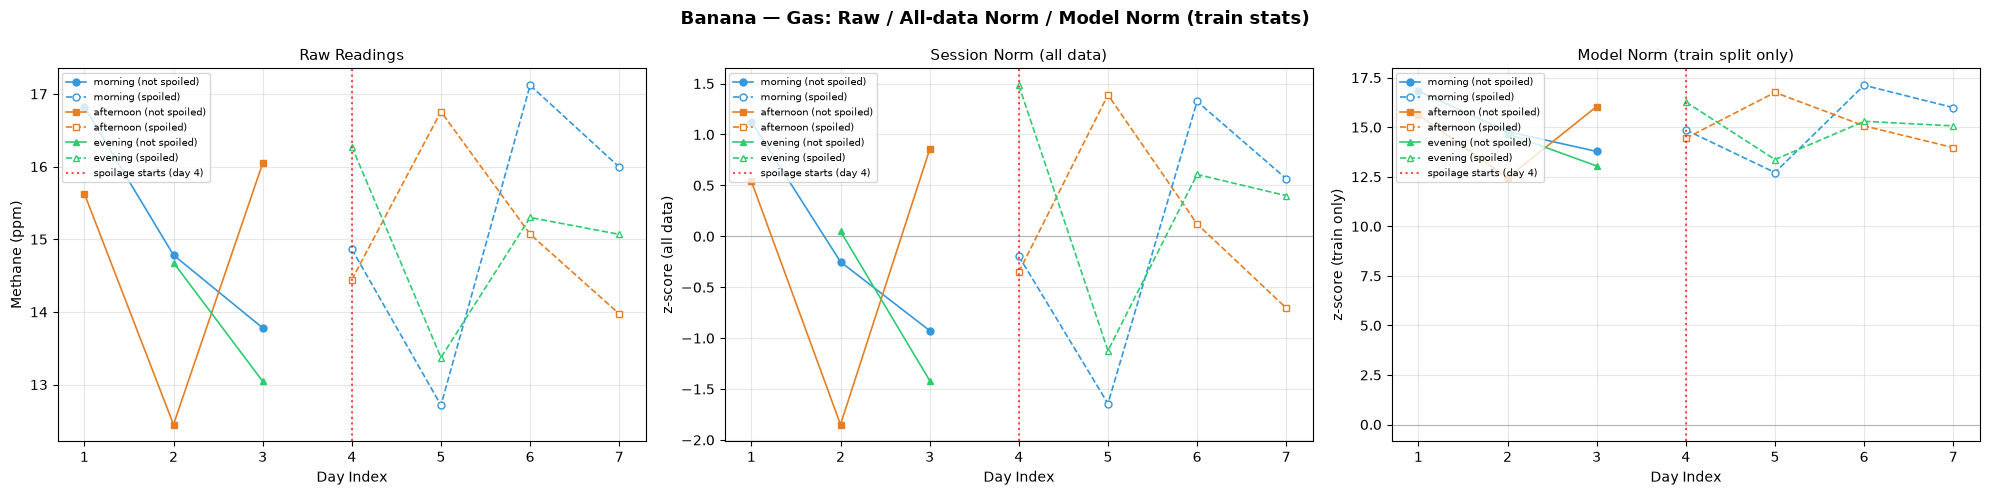

  Saved: gas_norm_compare_banana.png


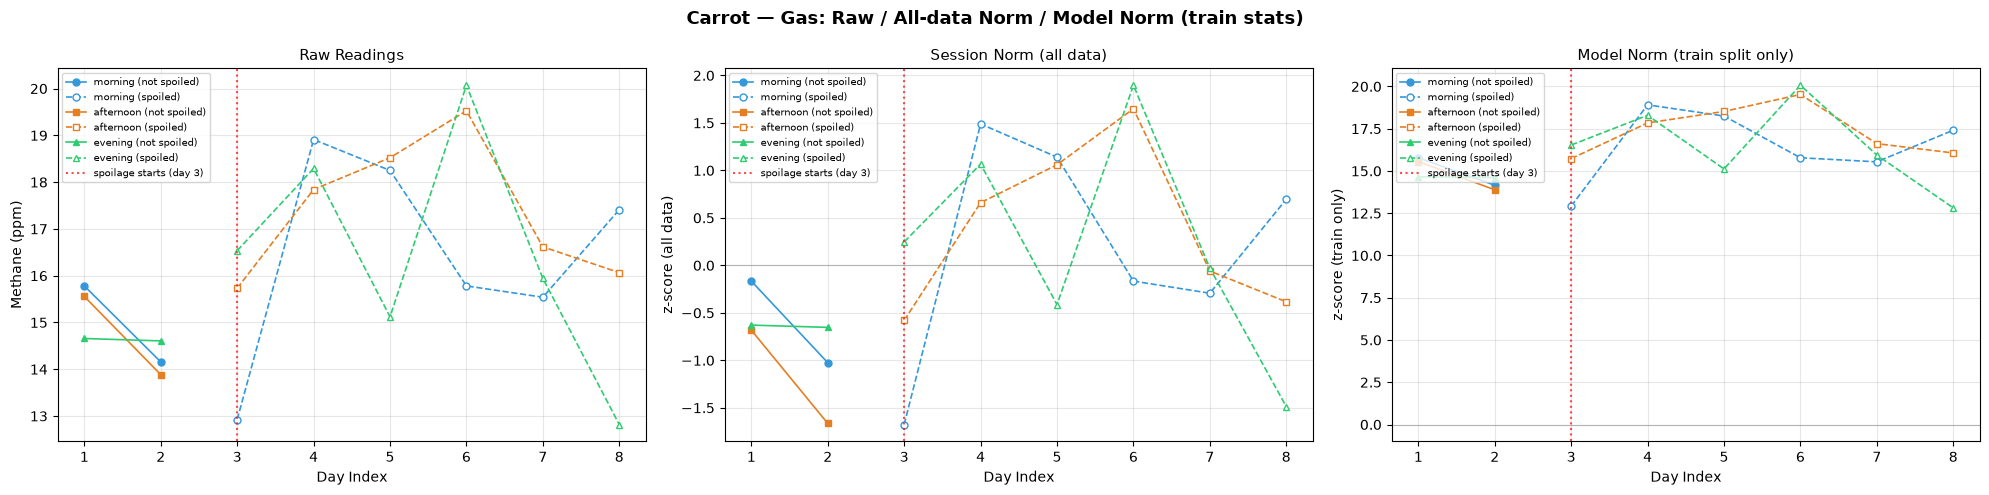

  Saved: gas_norm_compare_carrot.png


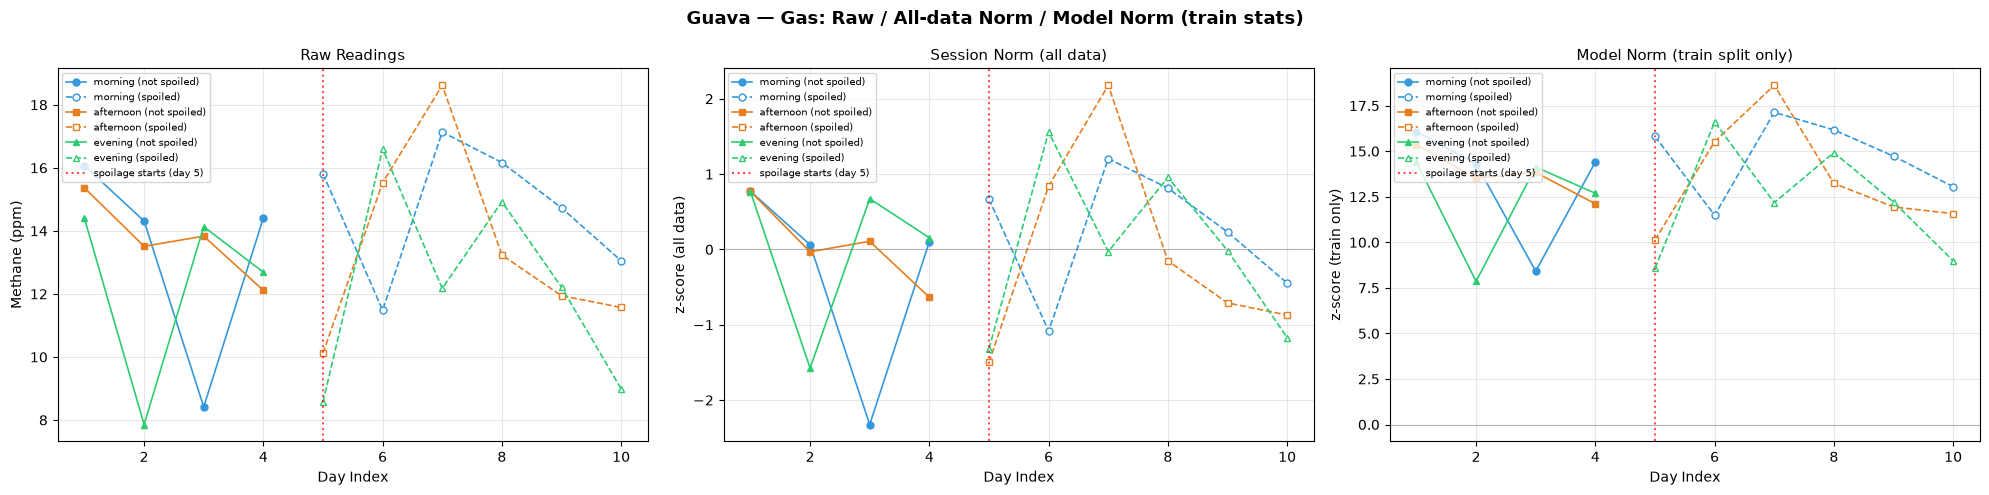

  Saved: gas_norm_compare_guava.png


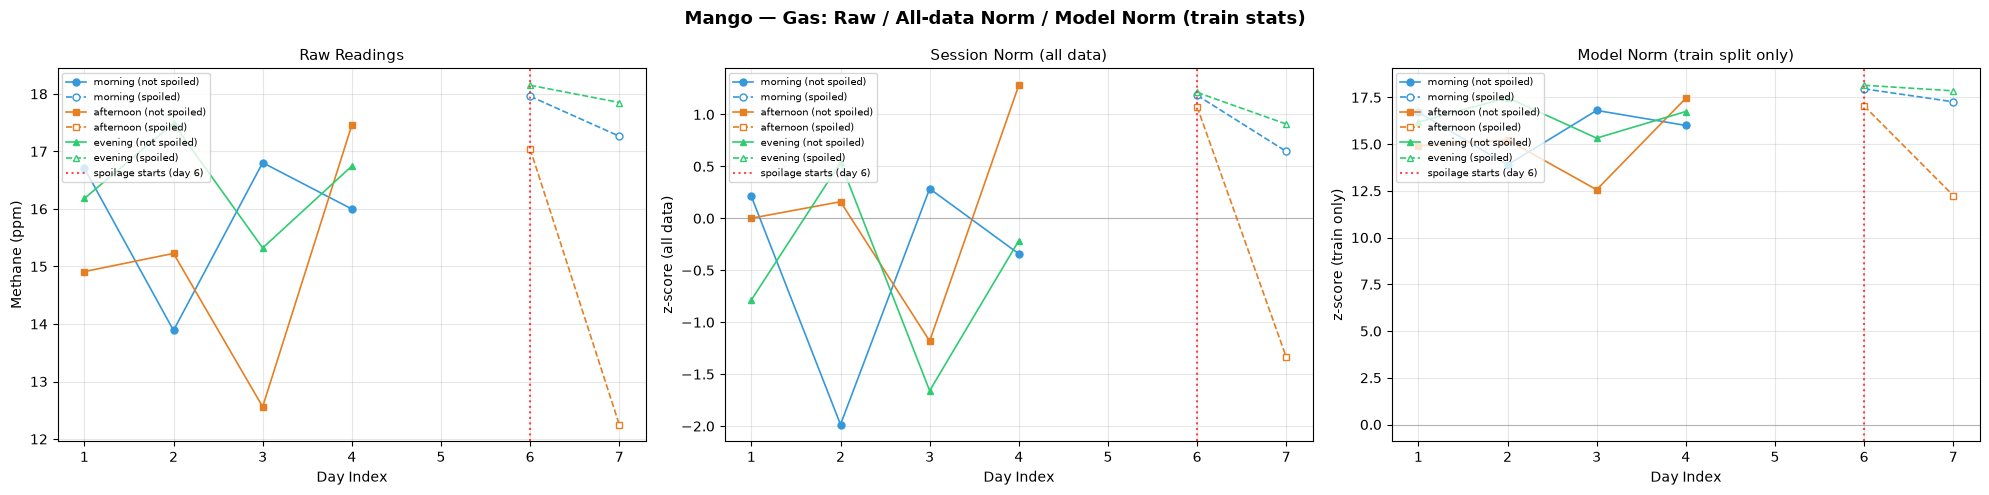

  Saved: gas_norm_compare_mango.png


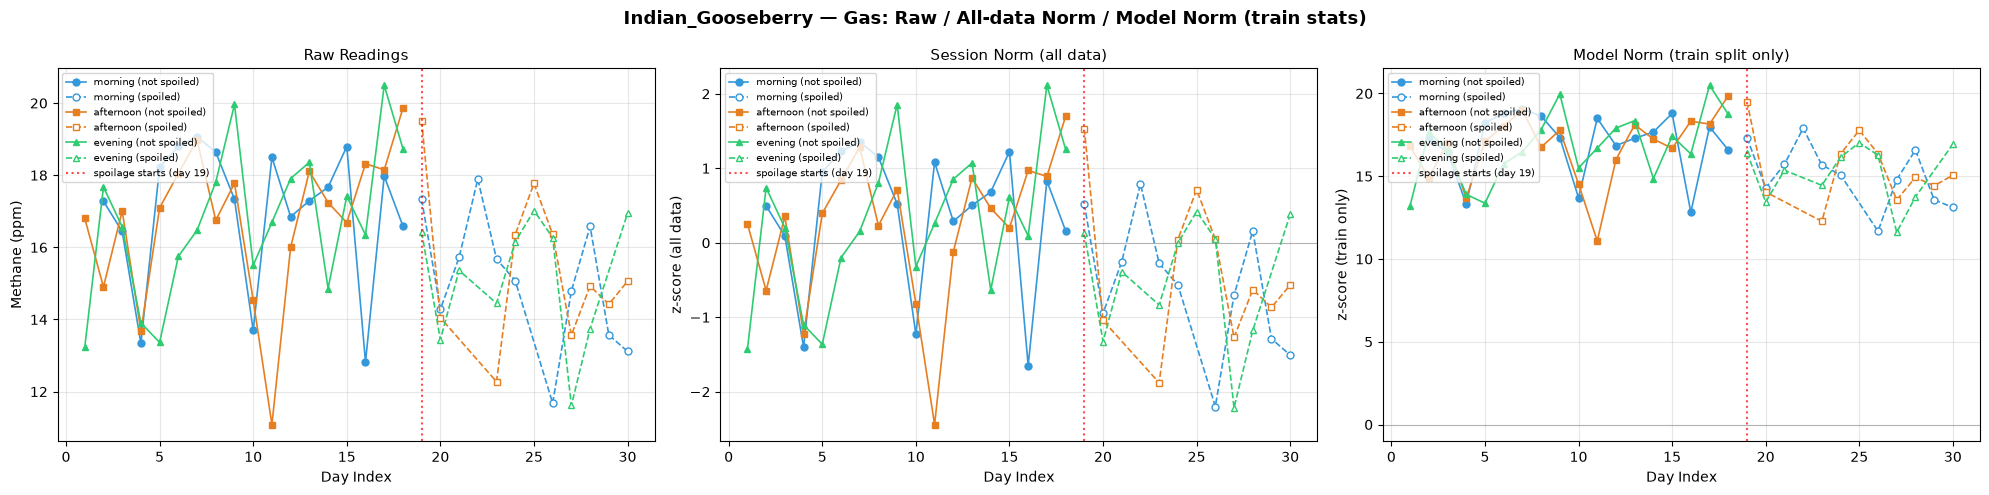

  Saved: gas_norm_compare_indian_gooseberry.png


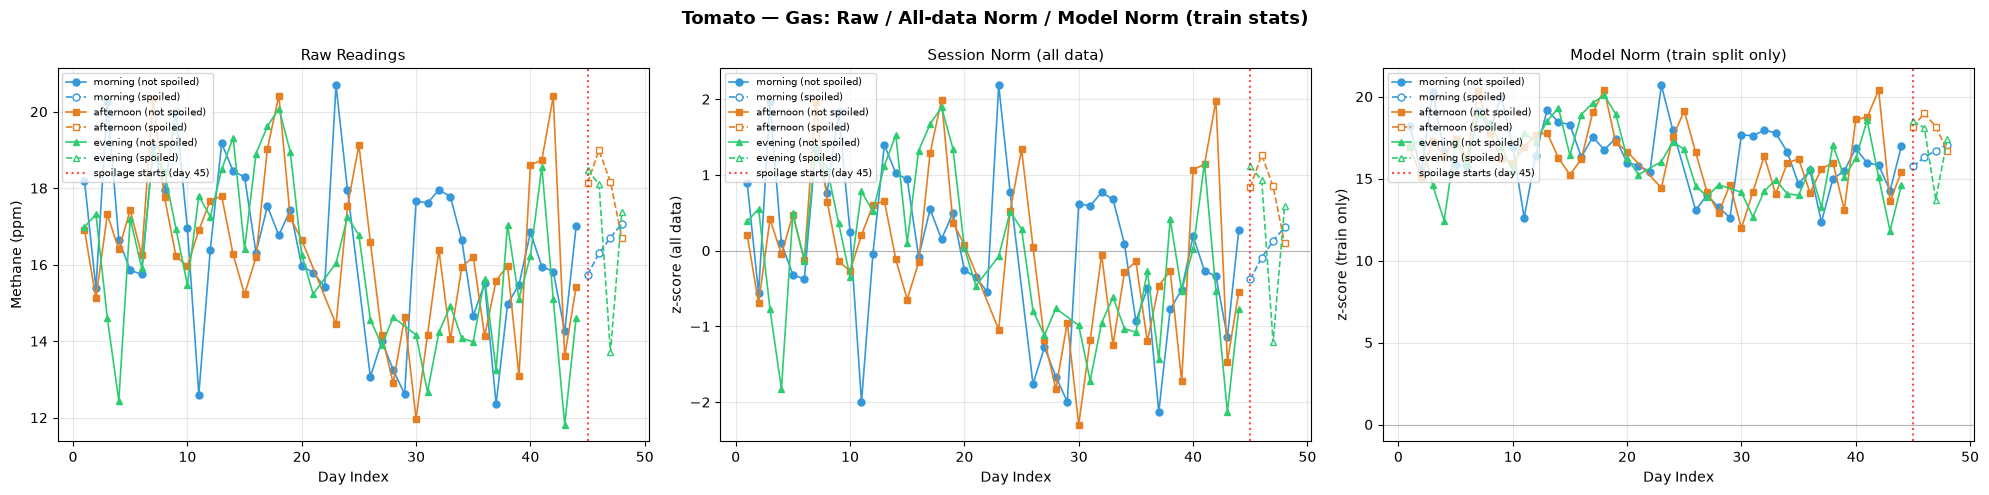

  Saved: gas_norm_compare_tomato.png


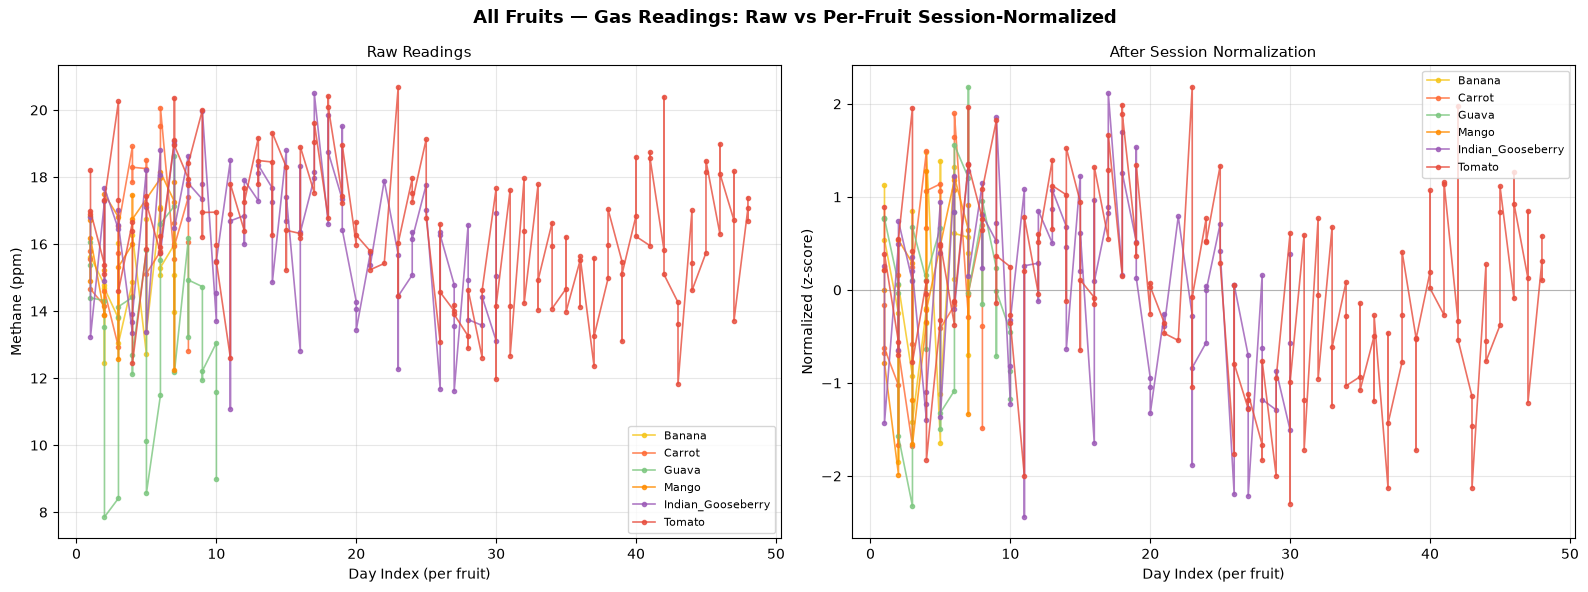

     gas_norm_all_fruits.png

Plots saved to: /Users/sjanani2073/Desktop/newscript/runs/gas_norm_plots


In [67]:
PLOTS_DIR = Path("~/Desktop/newscript/runs/gas_norm_plots").expanduser()  # NEW root
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

records = load_gas_data(MANIFESTS)
print(f"{len(records)} session gas readings loaded")

records, stats = apply_session_normalization(records)
print_normalization_stats(stats)

records = apply_saved_normalization(records, GAS_NORM_OUT)
print_normalization_stats(stats)

plot_per_fruit_three(records, PLOTS_DIR)
plot_combined(records, PLOTS_DIR)
print(f"\nPlots saved to: {PLOTS_DIR}")

# 6. Train/Test/Val Splits

In [68]:
LABELS     = ["not_spoiled", "spoiled"]
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

In [69]:
def make_splits(manifests_dir: Path, seed: int):
    master_path = manifests_dir / "master_manifest.csv"
    if not master_path.exists():
        print(f"ERROR: master_manifest.csv not found in {manifests_dir}")
        return

    with open(master_path, newline="") as f:
        reader = csv.DictReader(f)
        fieldnames = list(reader.fieldnames)
        rows = list(reader)

    instance_map = defaultdict(list)
    for i, row in enumerate(rows):
        key = (row["fruit"], row["label"])
        instance_map[key].append(i)

    split_assignments = {}   # row_index -> "train" | "val" | "test"
    split_counts = {"train": 0, "val": 0, "test": 0}

    for (fruit, label), indices in sorted(instance_map.items()):
        day_map = defaultdict(list)
        day_dates = {}
        for i in indices:
            day = rows[i]["corrected_day_index"]
            day_map[day].append(i)
            day_dates[day] = rows[i]["actual_date"]

        # Chronological order (by actual_date, not a random shuffle) so a split
        # never trains on days that come after what it validates/tests on within
        # the same (fruit, label) stratum.
        days = sorted(day_map.keys(), key=lambda d: day_dates[d])

        n = len(days)
        n_train = max(1, round(n * TRAIN_RATIO))
        n_val   = max(1, round(n * VAL_RATIO))
        n_test  = n - n_train - n_val

        if n_test < 1:
            n_test  = 1
            n_train = n - n_val - n_test
        if n_val < 1:
            n_val   = 1
            n_train = n - n_val - n_test
        if n_train < 1:
            n_train = 1

        # Chronological prefix/suffix split within this (fruit, label) stratum:
        # earliest days -> train, next -> val, most recent -> test.
        train_days = days[:n_train]
        val_days   = days[n_train:n_train + n_val]
        test_days  = days[n_train + n_val:]

        for day in train_days:
            for i in day_map[day]:
                split_assignments[i] = "train"
                split_counts["train"] += 1

        for day in val_days:
            for i in day_map[day]:
                split_assignments[i] = "val"
                split_counts["val"] += 1

        for day in test_days:
            for i in day_map[day]:
                split_assignments[i] = "test"
                split_counts["test"] += 1

        print(f"  {fruit:20s} {label:12s} | {n} days (chronological) -> "
              f"train={len(train_days)} val={len(val_days)} test={len(test_days)}")

    for i, row in enumerate(rows):
        row["split"] = split_assignments.get(i, "train")

    if "split" not in fieldnames:
        fieldnames.append("split")

    with open(master_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)
    print(f"\n     master_manifest.csv updated")

    for fruit in FRUITS:
        slug = fruit.lower().replace(" ", "_")
        fruit_path = manifests_dir / f"{slug}_manifest.csv"
        if not fruit_path.exists():
            continue

        with open(fruit_path, newline="") as f:
            reader = csv.DictReader(f)
            fruit_fields = list(reader.fieldnames)
            fruit_rows   = list(reader)

        if "split" not in fruit_fields:
            fruit_fields.append("split")

        master_lookup = {
            (r["fruit"], r["label"], r["actual_date"]): r["split"]
            for r in rows
        }

        for row in fruit_rows:
            key = (row["fruit"], row["label"], row["actual_date"])
            row["split"] = master_lookup.get(key, "train")

        with open(fruit_path, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=fruit_fields, extrasaction="ignore")
            writer.writeheader()
            writer.writerows(fruit_rows)

        print(f" {fruit_path.name} updated")

    per_fruit_counts = defaultdict(lambda: defaultdict(int))
    for row in rows:
        per_fruit_counts[row["fruit"]][row["split"]] += 1

    info = {
        "seed":        seed,
        "train_ratio": TRAIN_RATIO,
        "val_ratio":   VAL_RATIO,
        "test_ratio":  TEST_RATIO,
        "total_sessions": len(rows),
        "split_counts": split_counts,
        "per_fruit": {
            fruit: dict(counts)
            for fruit, counts in per_fruit_counts.items()
        },
        "note": "Splits are chronological (by actual_date) within each (fruit, label) stratum: "
                "the earliest days go to train, the next to val, and the most recent to test, "
                "independently per label so both classes are represented in every split. "
                "Never regenerate -- use this file as the frozen record."
    }

    info_path = manifests_dir / "splits_info.json"
    with open(info_path, "w") as f:
        json.dump(info, f, indent=2)

    print(f"\n  splits_info.json saved")
    print(f"\nFinal split counts:")
    print(f"  train : {split_counts['train']} sessions")
    print(f"  val   : {split_counts['val']} sessions")
    print(f"  test  : {split_counts['test']} sessions")
    print(f"  total : {len(rows)} sessions")
    print(f"\nDo not rerun this script.")


In [70]:
# Splits were regenerated under the corrected chronological-per-label methodology above.
# Uncomment and run once, then re-freeze.
make_splits(MANIFESTS, seed=42)


  Banana               not_spoiled  | 3 days (chronological) -> train=1 val=1 test=1
  Banana               spoiled      | 4 days (chronological) -> train=2 val=1 test=1
  Carrot               not_spoiled  | 2 days (chronological) -> train=1 val=1 test=0
  Carrot               spoiled      | 7 days (chronological) -> train=5 val=1 test=1
  Guava                not_spoiled  | 4 days (chronological) -> train=2 val=1 test=1
  Guava                spoiled      | 6 days (chronological) -> train=4 val=1 test=1
  Indian_Gooseberry    not_spoiled  | 18 days (chronological) -> train=13 val=3 test=2
  Indian_Gooseberry    spoiled      | 12 days (chronological) -> train=8 val=2 test=2
  Mango                not_spoiled  | 5 days (chronological) -> train=3 val=1 test=1
  Mango                spoiled      | 3 days (chronological) -> train=1 val=1 test=1
  Tomato               not_spoiled  | 44 days (chronological) -> train=31 val=7 test=6
  Tomato               spoiled      | 4 days (chronological)

# 7. TriModal Dataset Demo

In [71]:
FRUIT_LIST   = ["Banana", "Carrot", "Guava", "Indian_Gooseberry", "Mango", "Tomato"]
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}

SESSION_TO_IDX = {"morning": 0, "afternoon": 1, "evening": 2}
LABEL_TO_IDX   = {"not_spoiled": 0, "spoiled": 1}

IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

IR_PATTERN   = re.compile(r"(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$", re.IGNORECASE)
SRGB_PATTERN = re.compile(r"^(\d{8})_(\d{6})[^/]*\.jpg$", re.IGNORECASE)

### Transforms

In [72]:
def get_rgb_transform(train: bool) -> transforms.Compose:
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

In [73]:
def get_ir_transform(train: bool) -> transforms.Compose:
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

### Helpers

In [74]:
def group_images_by_session(folder: Path, pattern: re.Pattern) -> dict:
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in sorted(folder.iterdir()):
        m = pattern.search(f.name)
        if not m:
            continue
        date_str  = m.group(1)
        time_str  = m.group(2)
        session   = hour_to_session(int(time_str[:2]))
        if session != "unknown":
            result[date_str][session].append(f)
    return dict(result)

In [75]:
def safe_float(val, default=0.0) -> float:
    try:
        return float(val)
    except (TypeError, ValueError):
        return default


def load_image(path: Path, transform) -> torch.Tensor:
    img = Image.open(path).convert("RGB")
    return transform(img)

### Dataset

In [76]:
class TrimodalDataset(Dataset):
    def __init__(
        self,
        manifest_path: str | Path,
        root: str | Path,
        train: bool = True,
        modality_dropout_prob: float = 0.3,
        exclude_flagged: bool = True,
        split: str | None = None,
        gas_norm_stats_path: str | Path | None = None,
        cache_images: bool = True,
        shared_pixel_cache: dict | None = None,
        gas_only: bool = False,
    ):
        self.root                  = Path(root)
        self.train                 = train
        self.modality_dropout_prob = modality_dropout_prob
        self.rgb_transform         = get_rgb_transform(train)
        self.ir_transform          = get_ir_transform(train)

        self.gas_norm_stats = None
        if gas_norm_stats_path is not None:
            with open(gas_norm_stats_path) as f:
                self.gas_norm_stats = json.load(f)["stats"]
            print(f"Gas norm stats loaded from {gas_norm_stats_path}")

        with open(manifest_path, newline="") as f:
            all_rows = list(csv.DictReader(f))

        if exclude_flagged:
            all_rows = [r for r in all_rows if r.get("exclude", "").strip().lower() != "true"]

        if split is not None:
            all_rows = [r for r in all_rows if r.get("split", "").strip().lower() == split.lower()]

        self.samples = []
        self._build_samples(all_rows)
        self.gas_only = gas_only
        self._image_cache = {}
        if not gas_only:
            self._build_image_index()

        self._pixel_cache: dict = {}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache = shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).', flush=True)
            elif cache_images:
                self._warmup_pixel_cache()

        print(f"TrimodalDataset: {len(self.samples)} sessions "
              f"({'train' if train else 'val/test'}, split={split})")

    def _build_samples(self, rows):
        for row in rows:
            fruit      = row["fruit"]
            label      = row["label"]
            date_str   = row["actual_date"]
            global_day = int(row["corrected_day_index"])
            days_until = safe_float(row.get("days_until_spoilage", ""), default=-1.0)

            for session in ["morning", "afternoon", "evening"]:
                sess_idx = SESSION_TO_IDX[session]

                # Check IR availability for this session
                ir_count = safe_float(row.get(f"ir_{session}_count", 0))
                ir_avail = ir_count > 0

                ir_tmin  = safe_float(row.get(f"ir_{session}_tmin",   ""), 0.0)
                ir_tmax  = safe_float(row.get(f"ir_{session}_tmax",   ""), 0.0)
                ir_trange = safe_float(row.get(f"ir_{session}_trange", ""), 0.0)

                # Check sRGB availability
                srgb_count = safe_float(row.get(f"srgb_{session}_count", 0))
                srgb_avail = srgb_count > 0

                # Check gas availability — handle TRUE/True/true
                gas_present_key = f"methane_{session}_present"
                gas_avail = row.get(gas_present_key, "").strip().upper() == "TRUE"

                mean_ppm  = safe_float(row.get(f"methane_{session}_ppm",   ""), 0.0)
                std_ppm   = safe_float(row.get(f"methane_{session}_std",   ""), 0.0)
                left_ppm  = safe_float(row.get(f"methane_{session}_left",  ""), 0.0)
                right_ppm = safe_float(row.get(f"methane_{session}_right", ""), 0.0)
                asym_ppm  = abs(left_ppm - right_ppm)

                if not ir_avail and not srgb_avail and not gas_avail:
                    continue

                self.samples.append({
                    "fruit":               fruit,
                    "label":               label,
                    "actual_date":         date_str,
                    "corrected_day_index": global_day,
                    "session":             session,
                    "session_idx":         sess_idx,
                    "fruit_idx":           FRUIT_TO_IDX.get(fruit, 0),
                    "label_idx":           LABEL_TO_IDX.get(label, 0),
                    "days_until_spoilage": days_until,
                    # IR scalars
                    "ir_tmin":    ir_tmin,
                    "ir_tmax":    ir_tmax,
                    "ir_trange":  ir_trange,
                    # Gas features
                    "gas_mean":   mean_ppm,
                    "gas_std":    std_ppm,
                    "gas_left":   left_ppm,
                    "gas_right":  right_ppm,
                    "gas_asym":   asym_ppm,
                    # Availability (before dropout)
                    "rgb_available": srgb_avail,
                    "ir_available":  ir_avail,
                    "gas_available": gas_avail,
                })


    def _build_image_index(self):
        label_map = {
            "not_spoiled": "Not_spoiled",
            "spoiled":     "Spoiled",
        }
        for fruit in FRUIT_LIST:
            for label_key, label_folder in label_map.items():
                base = self.root / "Classified" / fruit / label_folder

                rgb_paths = group_images_by_session(base / "sRGB_images", SRGB_PATTERN)
                ir_paths  = group_images_by_session(find_ir_folder(base),  IR_PATTERN)

                for date_str, sessions in rgb_paths.items():
                    for session, paths in sessions.items():
                        key = (fruit, label_key, date_str, session)
                        if key not in self._image_cache:
                            self._image_cache[key] = {"rgb": [], "ir": []}
                        self._image_cache[key]["rgb"] = paths

                for date_str, sessions in ir_paths.items():
                    for session, paths in sessions.items():
                        key = (fruit, label_key, date_str, session)
                        if key not in self._image_cache:
                            self._image_cache[key] = {"rgb": [], "ir": []}
                        self._image_cache[key]["ir"] = paths

        banana_normal_ir = group_images_by_session(
            find_ir_folder(self.root / "Normal" / "Banana"), IR_PATTERN
        )
        spoiled_srgb_dates = {
            date for (fruit, label, date, sess) in self._image_cache
            if fruit == "Banana" and label == "spoiled"
        }
        for date_str, sessions in banana_normal_ir.items():
            if date_str in spoiled_srgb_dates:
                for session, paths in sessions.items():
                    key = ("Banana", "spoiled", date_str, session)
                    if key not in self._image_cache:
                        self._image_cache[key] = {"rgb": [], "ir": []}
                    if not self._image_cache[key].get("ir"):
                        self._image_cache[key]["ir"] = paths

    def _load_cached(self, path, transform):
        cached_pixels = self._pixel_cache.get(str(path))
        if cached_pixels is not None:
            from PIL import Image as PILImage
            pil = PILImage.fromarray(cached_pixels.permute(1, 2, 0).numpy())
            return transform(pil)
        return load_image(path, transform)

    def _warmup_pixel_cache(self):
        import numpy as np
        all_paths = set()
        for v in self._image_cache.values():
            all_paths.update(v.get("rgb", []))
            all_paths.update(v.get("ir",  []))
        total = len(all_paths)
        print(f"  Warming up image cache: {total} images...", flush=True)
        for i, path in enumerate(all_paths):
            if str(path) in self._pixel_cache:
                continue
            try:
                from PIL import Image as PILImage
                img = PILImage.open(path).convert("RGB")
                img = self.rgb_transform.transforms[0](img)  # Resize only
                arr = torch.from_numpy(np.array(img))
                self._pixel_cache[str(path)] = arr.permute(2, 0, 1)
            except Exception:
                pass
            if (i + 1) % 500 == 0 or (i + 1) == total:
                mb = sum(t.nbytes for t in self._pixel_cache.values()) / (1024**2)
                print(f"  {i+1}/{total} cached  ({mb:.0f} MB used)", flush=True)
        print(f"  Cache ready. {len(self._pixel_cache)} images in RAM.", flush=True)

    def _normalize_gas(self, fruit: str, session: str, mean_ppm: float,
                        std_ppm: float, left_ppm: float, right_ppm: float):
        if self.gas_norm_stats is None:
            return mean_ppm, std_ppm, left_ppm, right_ppm

        s = self.gas_norm_stats.get(fruit, {}).get(session, {})

        def norm(val, key):
            stat = s.get(key, {"mean": 0.0, "std": 1.0})
            return (val - stat["mean"]) / stat["std"]

        return (
            norm(mean_ppm,  "mean_ppm"),
            norm(std_ppm,   "std_ppm"),
            norm(left_ppm,  "left_ppm"),
            norm(right_ppm, "right_ppm"),
        )

    def _apply_dropout(self, rgb_avail, ir_avail, gas_avail):
        if not self.train:
            return rgb_avail, ir_avail, gas_avail

        while True:
            r = rgb_avail and (random.random() > self.modality_dropout_prob)
            i = ir_avail  and (random.random() > self.modality_dropout_prob)
            g = gas_avail and (random.random() > self.modality_dropout_prob)
            # Keep at least one
            if r or i or g:
                return r, i, g

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        fruit      = s["fruit"]
        label      = s["label"]
        date_str   = s["actual_date"]
        session    = s["session"]
        sess_idx   = s["session_idx"]
        rgb_avail, ir_avail, gas_avail = self._apply_dropout(
            s["rgb_available"], s["ir_available"], s["gas_available"]
        )

        cache_key = (fruit, label, date_str, session)
        cached    = self._image_cache.get(cache_key, {"rgb": [], "ir": []})

        if not self.gas_only and rgb_avail and cached["rgb"]:
            rgb_tensors = torch.stack([
                self._load_cached(p, self.rgb_transform) for p in cached["rgb"]
            ])  # [N, 3, 224, 224]
        else:
            rgb_avail   = False
            rgb_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)

        if not self.gas_only and ir_avail and cached["ir"]:
            ir_tensors = torch.stack([
                self._load_cached(p, self.ir_transform) for p in cached["ir"]
            ])  # [N, 3, 224, 224]
        else:
            ir_avail   = False
            ir_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)

        ir_scalars = torch.tensor(
            [s["ir_tmin"], s["ir_tmax"], s["ir_trange"]], dtype=torch.float32
        )
        if not ir_avail:
            ir_scalars = torch.zeros(3)
            
        if gas_avail:
            mean_ppm, std_ppm, left_ppm, right_ppm = self._normalize_gas(
                fruit, session,
                s["gas_mean"], s["gas_std"], s["gas_left"], s["gas_right"]
            )
            asym = abs(left_ppm - right_ppm)
            gas = torch.tensor([
                mean_ppm, std_ppm, left_ppm, right_ppm, asym, float(sess_idx) / 2.0,
            ], dtype=torch.float32)
        else:
            gas = torch.zeros(6)

        return {
            "rgb_images":           rgb_tensors,          # [N, 3, 224, 224]
            "ir_images":            ir_tensors,           # [N, 3, 224, 224]
            "ir_scalars":           ir_scalars,           # [3]
            "gas":                  gas,                  # [6]
            "rgb_available":        torch.tensor(rgb_avail,  dtype=torch.bool),
            "ir_available":         torch.tensor(ir_avail,   dtype=torch.bool),
            "gas_available":        torch.tensor(gas_avail,  dtype=torch.bool),
            "fruit_idx":            torch.tensor(s["fruit_idx"],   dtype=torch.long),
            "session_idx":          torch.tensor(sess_idx,         dtype=torch.long),
            "label":                torch.tensor(s["label_idx"],   dtype=torch.long),
            "days_until_spoilage":  torch.tensor(s["days_until_spoilage"], dtype=torch.float32),
            "fruit":                fruit,
            "actual_date":          date_str,
            "corrected_day_index":  s["corrected_day_index"],
        }

### Collate function

In [77]:
def trimodal_collate(batch):
    return {
        "rgb_images":  [s["rgb_images"] for s in batch],
        "ir_images":   [s["ir_images"]  for s in batch],

        "ir_scalars":           torch.stack([s["ir_scalars"]          for s in batch]),
        "gas":                  torch.stack([s["gas"]                 for s in batch]),
        "rgb_available":        torch.stack([s["rgb_available"]       for s in batch]),
        "ir_available":         torch.stack([s["ir_available"]        for s in batch]),
        "gas_available":        torch.stack([s["gas_available"]       for s in batch]),
        "fruit_idx":            torch.stack([s["fruit_idx"]           for s in batch]),
        "session_idx":          torch.stack([s["session_idx"]         for s in batch]),
        "label":                torch.stack([s["label"]               for s in batch]),
        "days_until_spoilage":  torch.stack([s["days_until_spoilage"] for s in batch]),

        "fruit":               [s["fruit"]               for s in batch],
        "actual_date":         [s["actual_date"]         for s in batch],
        "corrected_day_index": [s["corrected_day_index"] for s in batch],
    }

### Check

In [78]:
ds = TrimodalDataset(
    manifest_path = MANIFESTS / "master_manifest.csv",
    root          = ROOT,
    train         = False,
    split         = "train",
    gas_norm_stats_path = GAS_NORM_OUT,
)

print(f"\nTotal samples: {len(ds)}")
sample = ds[0]
print(f"  fruit:             {sample['fruit']}")
print(f"  date:              {sample['actual_date']}")
print(f"  session_idx:       {sample['session_idx']}")
print(f"  label:             {sample['label']}")
print(f"  days_until_spoil:  {sample['days_until_spoilage']}")
print(f"  rgb_images shape:  {sample['rgb_images'].shape}")
print(f"  ir_images shape:   {sample['ir_images'].shape}")
print(f"  gas:               {sample['gas']}")
print(f"  rgb_available:     {sample['rgb_available']}")

loader = DataLoader(ds, batch_size=4, shuffle=True,
                    collate_fn=trimodal_collate, num_workers=0)
batch = next(iter(loader))
print(f"\nBatch gas shape:  {batch['gas'].shape}")
print(f"Batch labels:     {batch['label']}")

Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

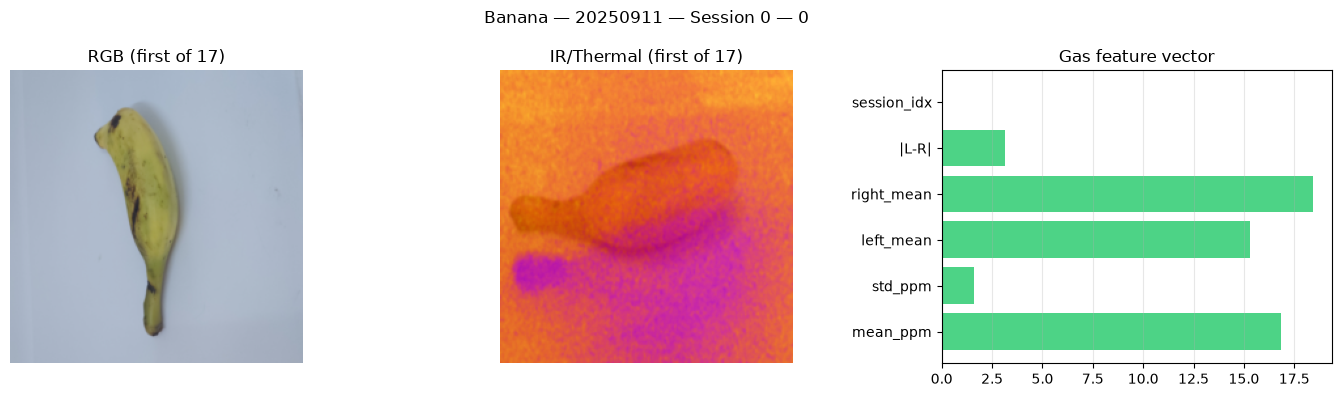

In [79]:
sample = ds[0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f"{sample['fruit']} — {sample['actual_date']} — "
             f"Session {sample['session_idx'].item()} — {sample['label']}", fontsize=12)

rgb_img = sample["rgb_images"][0].permute(1,2,0).numpy()
rgb_img = (rgb_img * 0.225 + 0.45).clip(0,1)
axes[0].imshow(rgb_img)
axes[0].set_title("RGB (first of 17)")
axes[0].axis("off")

ir_img = sample["ir_images"][0].permute(1,2,0).numpy()
ir_img = (ir_img - ir_img.min()) / (ir_img.max() - ir_img.min() + 1e-8)
axes[1].imshow(ir_img, cmap="inferno")
axes[1].set_title("IR/Thermal (first of 17)")
axes[1].axis("off")

gas = sample["gas"].numpy()
gas_labels = ["mean_ppm","std_ppm","left_mean","right_mean","|L-R|","session_idx"]
axes[2].barh(gas_labels, gas, color="#2ecc71", alpha=0.85)
axes[2].set_title("Gas feature vector")
axes[2].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Overfit Check

In [80]:
class DummyFusionModel(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.rgb_mlp = nn.Sequential(
            nn.Linear(3, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),
        )
        self.ir_mlp = nn.Sequential(
            nn.Linear(3, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),
        )

        self.ir_scalar_mlp = nn.Sequential(
            nn.Linear(3, hidden), nn.ReLU(),
        )

        self.gas_mlp = nn.Sequential(
            nn.Linear(6, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),
        )

        self.fruit_emb = nn.Embedding(6, hidden)

        fusion_dim = hidden * 5
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, hidden), nn.ReLU(),
        )
        self.cls_head  = nn.Linear(hidden, 2)    # spoiled / not_spoiled
        self.reg_head  = nn.Linear(hidden, 1)    # days until spoilage

    def forward(self, batch):
        device = next(self.parameters()).device
        rgb_feats = []
        for img_tensor in batch["rgb_images"]:
            img_tensor = img_tensor.to(device)
            feat = img_tensor.mean(dim=[0, 2, 3])
            rgb_feats.append(feat)
        rgb = torch.stack(rgb_feats)             # [B, 3]
        rgb = self.rgb_mlp(rgb)                  # [B, hidden]
        
        rgb_mask = batch["rgb_available"].to(device).float().unsqueeze(1)
        rgb = rgb * rgb_mask
        ir_feats = []
        for img_tensor in batch["ir_images"]:
            img_tensor = img_tensor.to(device)
            feat = img_tensor.mean(dim=[0, 2, 3])
            ir_feats.append(feat)
        ir = torch.stack(ir_feats)               # [B, 3]
        ir = self.ir_mlp(ir)                     # [B, hidden]

        ir_mask = batch["ir_available"].to(device).float().unsqueeze(1)
        ir = ir * ir_mask
        ir_scalars = batch["ir_scalars"].to(device)   # [B, 3]
        ir_s = self.ir_scalar_mlp(ir_scalars)         # [B, hidden]
        ir_s = ir_s * ir_mask
        
        gas = batch["gas"].to(device)                 # [B, 6]
        gas_feat = self.gas_mlp(gas)                  # [B, hidden]
        gas_mask = batch["gas_available"].to(device).float().unsqueeze(1)
        gas_feat = gas_feat * gas_mask

        fruit_idx = batch["fruit_idx"].to(device)     # [B]
        fruit_feat = self.fruit_emb(fruit_idx)        # [B, hidden]

        fused = torch.cat([rgb, ir, ir_s, gas_feat, fruit_feat], dim=1)  # [B, hidden*5]
        fused = self.fusion(fused)                    # [B, hidden]

        cls_logits = self.cls_head(fused)             # [B, 2]
        reg_out    = self.reg_head(fused).squeeze(1)  # [B]

        return cls_logits, reg_out

In [81]:
def run_overfit_check(manifest_path, root, gas_norm_stats_path, n_samples=8, n_steps=200):
    device = torch.device("mps" if torch.backends.mps.is_available()
                          else "cuda" if torch.cuda.is_available()
                          else "cpu")
    print(f"Device: {device}")

    ds = TrimodalDataset(
        manifest_path, root,
        train=False,  
        gas_norm_stats_path=gas_norm_stats_path,
    )

    subset = Subset(ds, list(range(min(n_samples, len(ds)))))
    loader = DataLoader(
        subset, batch_size=n_samples,
        shuffle=False, collate_fn=trimodal_collate, num_workers=0
    )
    batch = next(iter(loader))

    print(f"Overfitting on {n_samples} samples...")
    print(f"Labels in batch: {batch['label'].tolist()}")
    print(f"Days in batch:   {batch['days_until_spoilage'].tolist()}")
    print()

    model = DummyFusionModel(hidden=64).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

    cls_loss_fn = nn.CrossEntropyLoss()
    reg_loss_fn = nn.MSELoss()

    print(f"{'Step':>6}  {'cls_loss':>10}  {'reg_loss':>10}  {'total':>10}")
    print("-" * 44)

    for step in range(n_steps):
        model.train()
        optimiser.zero_grad()

        cls_logits, reg_out = model(batch)

        labels = batch["label"].to(device)
        days   = batch["days_until_spoilage"].to(device)

        cls_loss = cls_loss_fn(cls_logits, labels)
        reg_loss = reg_loss_fn(reg_out, days)
        total    = cls_loss + 0.1 * reg_loss 

        total.backward()
        optimiser.step()

        if step % 20 == 0 or step == n_steps - 1:
            print(f"{step:>6}  {cls_loss.item():>10.4f}  {reg_loss.item():>10.4f}  {total.item():>10.4f}")

    # Final check
    model.eval()
    with torch.no_grad():
        cls_logits, reg_out = model(batch)
        preds = cls_logits.argmax(dim=1)
        labels = batch["label"].to(device)
        acc = (preds == labels).float().mean().item()

    print(f"\nFinal accuracy on 8 samples: {acc*100:.1f}%")
    print(f"Predicted labels: {preds.tolist()}")
    print(f"True labels:      {labels.tolist()}")

    if acc >= 0.875:
        print("\n   PASSED — model can overfit. Data pipeline is correct.")
    else:
        print("\n  FAILED — model cannot overfit 8 samples.")
        print("  This means there is likely a bug in the data pipeline.")
        print("  Check: label assignments, gas values, image loading.")

In [82]:
run_overfit_check(
    manifest_path       = MANIFESTS / "master_manifest.csv",
    root                = ROOT,
    gas_norm_stats_path = GAS_NORM_OUT,
    n_samples = 8,
    n_steps   = 200,
)

Device: mps
Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 327 se